# Statistical Analysis of Personality-Adaptive Chatbot Performance
## Regulated vs Baseline Comparison

This notebook performs comprehensive statistical analysis including:
- **Data quality assessment** with visualizations
- **Descriptive statistics** (means, SDs, confidence intervals)
- **Effect size analysis** (Cohen's d)
- **Comparative visualizations**
- **Inferential statistics** (illustrative)

---

## Setup: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Enable inline plotting
%matplotlib inline

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## Load Analysis Functions

In [ ]:
# Import functions from the main script
from statistical_analysis import (
    load_and_prepare_data,
    assess_data_quality,
    convert_to_numeric,
    calculate_descriptive_statistics,
    calculate_effect_sizes,
    perform_inferential_tests
)

print("✓ Analysis functions loaded!")

✓ Analysis functions loaded!


---
## Step 1: Load and Prepare Data

Load the regulated and baseline datasets:

In [ ]:
df_regulated, df_baseline = load_and_prepare_data(
    regulated_path="merged/regulated.csv",
    baseline_path="merged/baseline.csv"
)

STEP 1: DATA LOADING AND PREPARATION

Regulated dataset shape: (59, 12)
Baseline dataset shape: (60, 8)

Personality Type Distribution (Regulated):
Personality_Type
A    30
B    29
Name: count, dtype: int64

Conversation IDs: 10 unique conversations


In [ ]:
# Display first few rows
print("\n📊 Regulated Dataset (first 3 rows):")
display(df_regulated[['MSG. NO.', 'Personality_Type', 'Conversation_ID', 
                       'DETECTION ACCURATE', 'REGULATION EFFECTIVE']].head(3))

print("\n📊 Baseline Dataset (first 3 rows):")
display(df_baseline[['MSG. NO.', 'Personality_Type', 'Conversation_ID',
                      'EMOTIONAL TONE APPROPRIATE', 'RELEVANCE & COHERENCE']].head(3))


📊 Regulated Dataset (first 3 rows):


,MSG. NO.,Personality_Type,Conversation_ID,DETECTION ACCURATE,REGULATION EFFECTIVE
0,A-1-1,A,A-1,YES,YES
1,A-1-2,A,A-1,YES,YES
2,A-1-3,A,A-1,YES,YES



📊 Baseline Dataset (first 3 rows):


,MSG. NO.,Personality_Type,Conversation_ID,EMOTIONAL TONE APPROPRIATE,RELEVANCE & COHERENCE
0,A-1-1,A,A-1,YES,YES
1,A-1-2,A,A-1,YES,YES
2,A-1-3,A,A-1,YES,YES


---
## Step 2: Data Quality Assessment

In [ ]:
quality_report = assess_data_quality(df_regulated, df_baseline)


STEP 2: DATA QUALITY ASSESSMENT

2.1 Missing Values Analysis:
--------------------------------------------------------------------------------

Regulated Dataset:
  ASSISTANT START: 50 (84.75%)

Baseline Dataset:
  ASSISTANT START: 50 (83.33%)
  EVALUATORS NOTES: 1 (1.67%)

2.2 Evaluation Metrics Distribution:
--------------------------------------------------------------------------------

Regulated Metrics:

  DETECTION ACCURATE:
    YES: 58 (98.3%)
    NOT SURE: 1 (1.7%)

  REGULATION EFFECTIVE:
    YES: 59 (100.0%)

  EMOTIONAL TONE APPROPRIATE:
    YES: 59 (100.0%)

  RELEVANCE & COHERENCE:
    YES: 59 (100.0%)

  PERSONALITY NEEDS ADDRESSED:
    YES: 59 (100.0%)

Baseline Metrics:

  EMOTIONAL TONE APPROPRIATE:
    YES: 60 (100.0%)

  RELEVANCE & COHERENCE:
    YES: 59 (98.3%)
    NO: 1 (1.7%)

  PERSONALITY NEEDS ADDRESSED:
    NO: 53 (88.3%)
    YES: 5 (8.3%)
    NOT SURE: 2 (3.3%)

2.3 Data Alignment Check:
---------------------------------------------------------------------

---
## Step 3: Visualize Data Quality

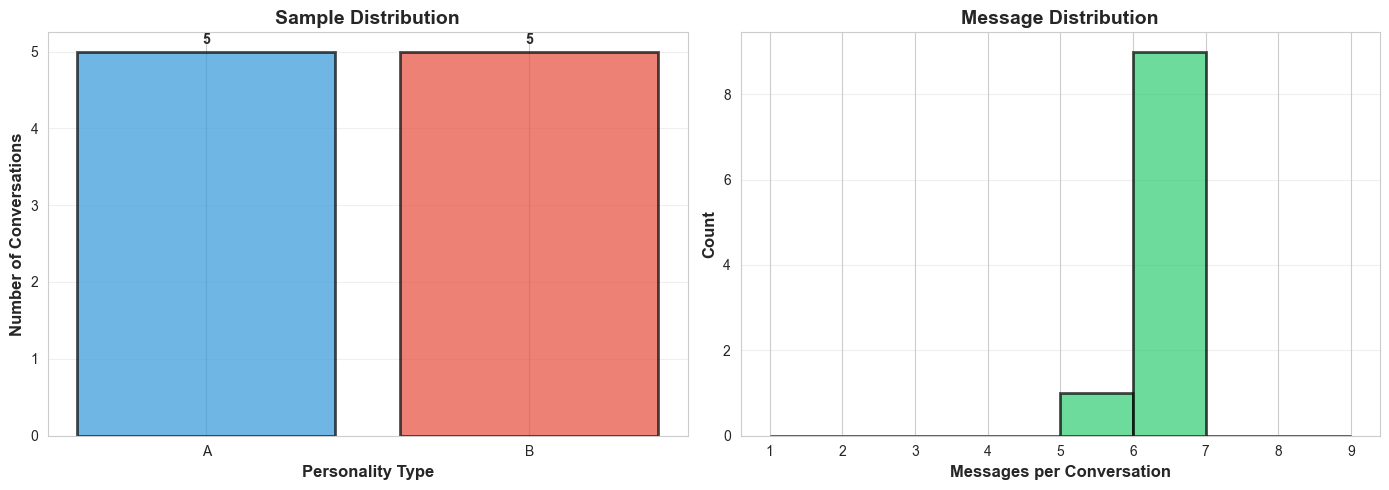

In [ ]:
# Sample Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_counts = df_regulated.groupby('Personality_Type')['Conversation_ID'].nunique()
axes[0].bar(reg_counts.index, reg_counts.values, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_xlabel('Personality Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Conversations', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(reg_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

msg_counts = df_regulated.groupby('Conversation_ID').size()
axes[1].hist(msg_counts, bins=range(1, 10), color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Messages per Conversation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Message Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

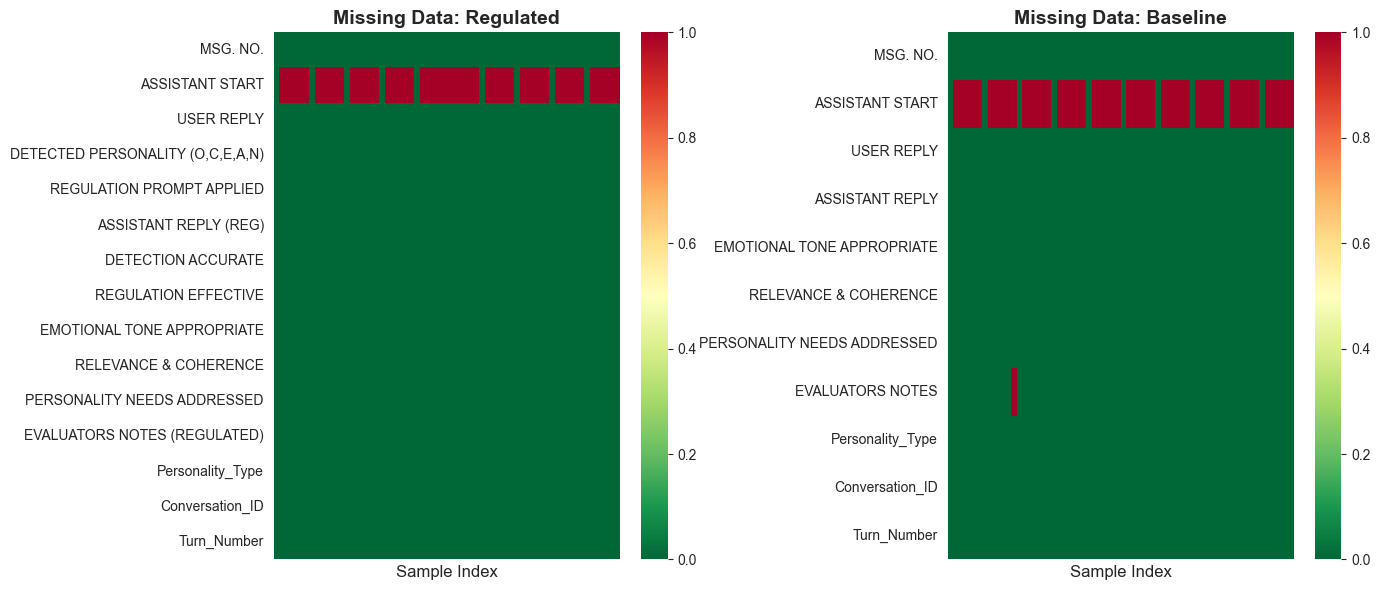

In [ ]:
# Missing Data Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

missing_reg = df_regulated.isnull().astype(int)
sns.heatmap(missing_reg.T, cmap='RdYlGn_r', cbar=True, ax=axes[0], 
            xticklabels=False, yticklabels=df_regulated.columns)
axes[0].set_title('Missing Data: Regulated', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index', fontsize=12)

missing_base = df_baseline.isnull().astype(int)
sns.heatmap(missing_base.T, cmap='RdYlGn_r', cbar=True, ax=axes[1],
            xticklabels=False, yticklabels=df_baseline.columns)
axes[1].set_title('Missing Data: Baseline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=12)

plt.tight_layout()
plt.show()

---
## Step 4: Convert Categorical to Numeric

In [ ]:
df_reg_numeric, df_base_numeric = convert_to_numeric(df_regulated, df_baseline)


STEP 4: CONVERTING CATEGORICAL TO NUMERIC

Converting Regulated metrics...
  ✓ DETECTION ACCURATE: 58 values converted
  ✓ REGULATION EFFECTIVE: 59 values converted
  ✓ EMOTIONAL TONE APPROPRIATE: 59 values converted
  ✓ RELEVANCE & COHERENCE: 59 values converted
  ✓ PERSONALITY NEEDS ADDRESSED: 59 values converted

Converting Baseline metrics...
  ✓ EMOTIONAL TONE APPROPRIATE: 60 values converted
  ✓ RELEVANCE & COHERENCE: 60 values converted
  ✓ PERSONALITY NEEDS ADDRESSED: 58 values converted


---
## Step 5: Descriptive Statistics

In [ ]:
df_stats = calculate_descriptive_statistics(df_reg_numeric, df_base_numeric)


STEP 5: DESCRIPTIVE STATISTICS

5.1 Common Metrics (Regulated vs Baseline):
--------------------------------------------------------------------------------

EMOTIONAL TONE APPROPRIATE:
  Regulated:  M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%
  Baseline:   M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%

RELEVANCE & COHERENCE:
  Regulated:  M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%
  Baseline:   M=0.983 (SD=0.129), 95% CI [0.950, 1.017], 98.3%

PERSONALITY NEEDS ADDRESSED:
  Regulated:  M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%
  Baseline:   M=0.086 (SD=0.283), 95% CI [0.012, 0.161], 8.6%

5.2 Regulated-Only Metrics:
--------------------------------------------------------------------------------

DETECTION ACCURATE:
  Regulated:  M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%

REGULATION EFFECTIVE:
  Regulated:  M=1.000 (SD=0.000), 95% CI [nan, nan], 100.0%


In [ ]:
print("\n📊 Descriptive Statistics Table:")
display(df_stats.round(3))


📊 Descriptive Statistics Table:


,Metric,Condition,N,Mean,SD,CI_Lower,CI_Upper,Percentage
0,EMOTIONAL TONE APPROPRIATE,Regulated,59,1.000,0.000,NaN,NaN,100.000
1,EMOTIONAL TONE APPROPRIATE,Baseline,60,1.000,0.000,NaN,NaN,100.000
2,RELEVANCE & COHERENCE,Regulated,59,1.000,0.000,NaN,NaN,100.000
3,RELEVANCE & COHERENCE,Baseline,60,0.983,0.129,0.950,1.017,98.333
4,PERSONALITY NEEDS ADDRESSED,Regulated,59,1.000,0.000,NaN,NaN,100.000
5,PERSONALITY NEEDS ADDRESSED,Baseline,58,0.086,0.283,0.012,0.161,8.621
6,DETECTION ACCURATE,Regulated,58,1.000,0.000,NaN,NaN,100.000
7,REGULATION EFFECTIVE,Regulated,59,1.000,0.000,NaN,NaN,100.000


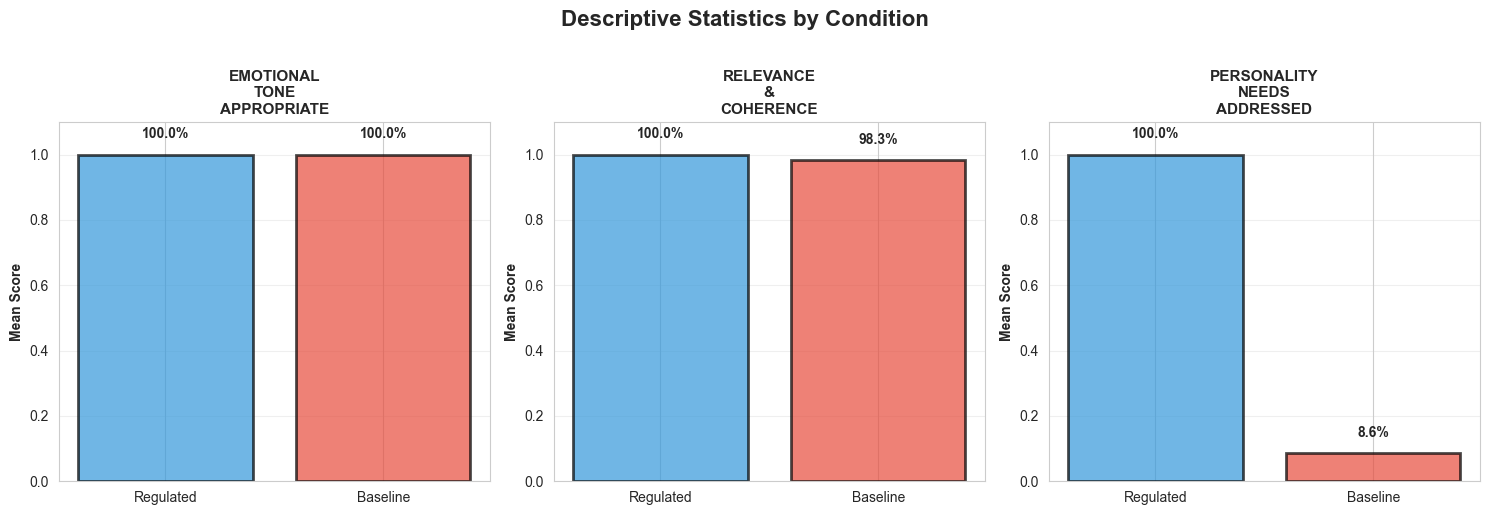

In [ ]:
# Visualize descriptive statistics
common_metrics = ['EMOTIONAL TONE APPROPRIATE', 'RELEVANCE & COHERENCE', 'PERSONALITY NEEDS ADDRESSED']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(common_metrics):
    metric_data = df_stats[df_stats['Metric'] == metric]
    if len(metric_data) > 0:
        conditions = metric_data['Condition'].tolist()
        means = metric_data['Mean'].tolist()
        colors = ['#3498db' if c == 'Regulated' else '#e74c3c' for c in conditions]
        
        bars = axes[i].bar(conditions, means, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
        axes[i].set_title(metric.replace(' ', '\n'), fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Mean Score', fontsize=10, fontweight='bold')
        axes[i].set_ylim([0, 1.1])
        axes[i].grid(axis='y', alpha=0.3)
        
        for j, (bar, mean) in enumerate(zip(bars, means)):
            axes[i].text(bar.get_x() + bar.get_width()/2, mean + 0.05, 
                        f'{mean*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Descriptive Statistics by Condition', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6: Effect Size Analysis (Cohen's d)

In [ ]:
df_effects = calculate_effect_sizes(df_reg_numeric, df_base_numeric)


STEP 6: EFFECT SIZE ANALYSIS (COHEN'S D)

Cohen's d Effect Sizes (Regulated vs Baseline):
--------------------------------------------------------------------------------
Metric                                   d        Interpretation  Direction
--------------------------------------------------------------------------------
EMOTIONAL TONE APPROPRIATE                 0.000 Negligible      Baseline > Regulated
RELEVANCE & COHERENCE                      0.182 Negligible      Regulated > Baseline
PERSONALITY NEEDS ADDRESSED                4.584 Large           Regulated > Baseline

Interpretation Guidelines (Cohen, 1988):
  |d| < 0.2: Negligible effect
  |d| < 0.5: Small effect
  |d| < 0.8: Medium effect
  |d| ≥ 0.8: Large effect


In [ ]:
print("\n📊 Effect Sizes Table:")
display(df_effects.round(3))


📊 Effect Sizes Table:


,Metric,Cohens_d,Interpretation,Regulated_Mean,Baseline_Mean,Difference
0,EMOTIONAL TONE APPROPRIATE,0.000,Negligible,1.0,1.000,0.000
1,RELEVANCE & COHERENCE,0.182,Negligible,1.0,0.983,0.017
2,PERSONALITY NEEDS ADDRESSED,4.584,Large,1.0,0.086,0.914


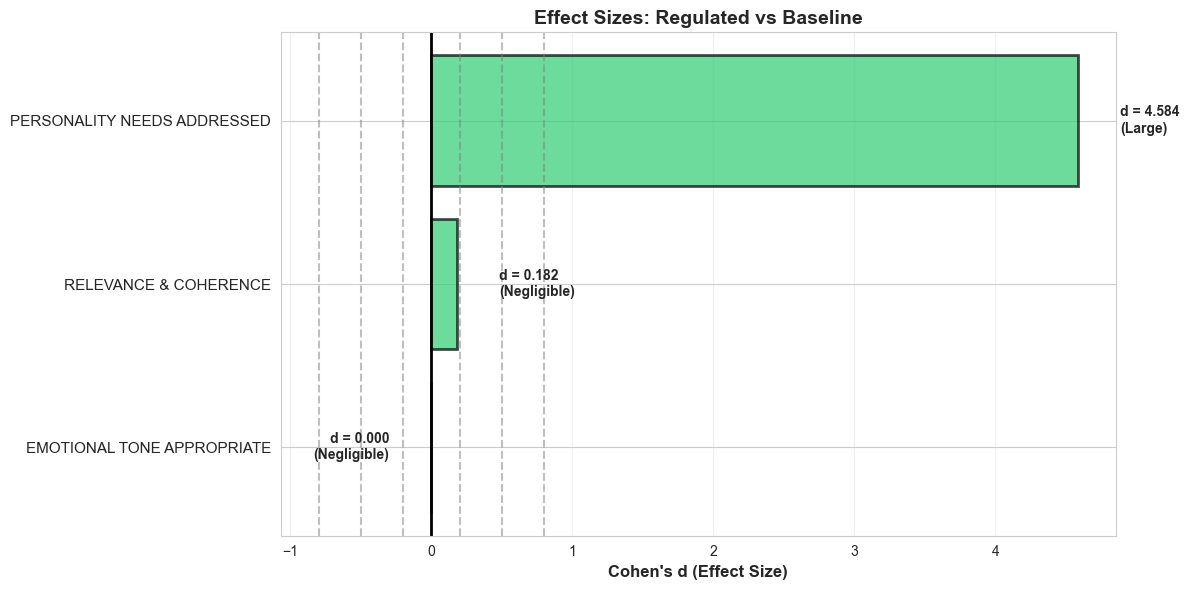

In [ ]:
# Visualize effect sizes
fig, ax = plt.subplots(figsize=(12, 6))

metrics = df_effects['Metric'].tolist()
cohens_d = df_effects['Cohens_d'].tolist()
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in cohens_d]

y_pos = np.arange(len(metrics))
bars = ax.barh(y_pos, cohens_d, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Reference lines
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
for val in [0.2, 0.5, 0.8]:
    ax.axvline(x=val, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axvline(x=-val, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Labels
for i, (d, interpretation) in enumerate(zip(cohens_d, df_effects['Interpretation'])):
    label_x = d + (0.3 if d > 0 else -0.3)
    ax.text(label_x, i, f'd = {d:.3f}\n({interpretation})', 
           va='center', ha='left' if d > 0 else 'right', fontweight='bold', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=11)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=12, fontweight='bold')
ax.set_title("Effect Sizes: Regulated vs Baseline", fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 7: Performance Comparison

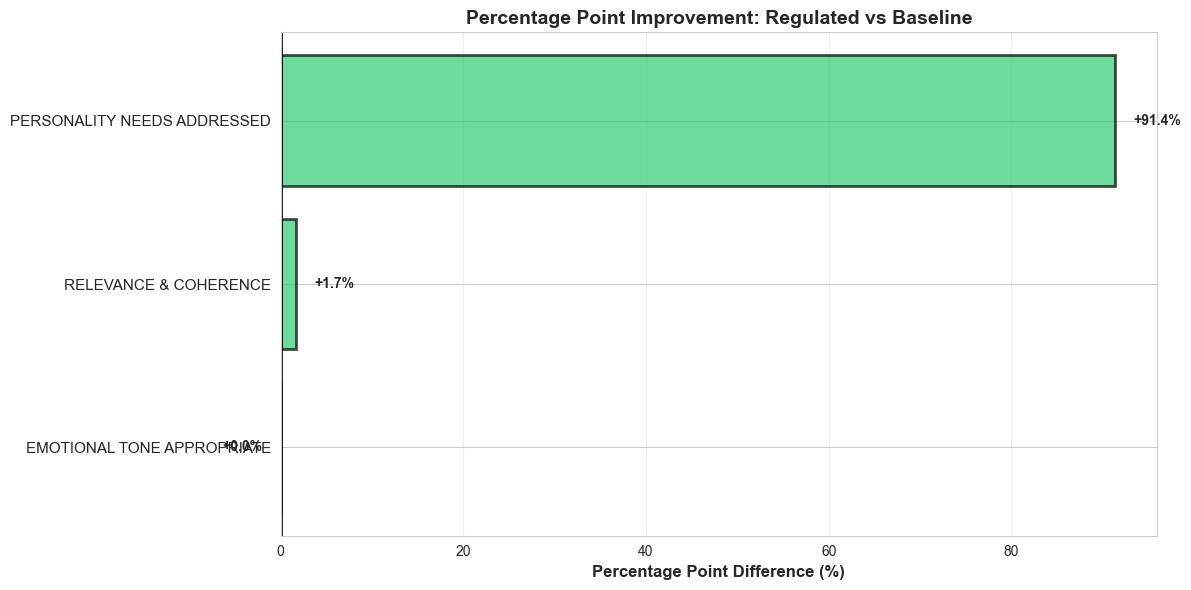

In [ ]:
# Percentage improvement
fig, ax = plt.subplots(figsize=(12, 6))

metrics = df_effects['Metric'].tolist()
improvement = (df_effects['Difference'] * 100).tolist()
colors = ['#2ecc71' if i > 0 else '#e74c3c' for i in improvement]

y_pos = np.arange(len(metrics))
bars = ax.barh(y_pos, improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)

# Value labels
for i, val in enumerate(improvement):
    label_x = val + (2 if val > 0 else -2)
    ax.text(label_x, i, f'{val:+.1f}%', 
           va='center', ha='left' if val > 0 else 'right', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=11)
ax.set_xlabel('Percentage Point Difference (%)', fontsize=12, fontweight='bold')
ax.set_title('Percentage Point Improvement: Regulated vs Baseline', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 8: Inferential Statistics (Illustrative)

**Note:** For illustration purposes only given the deterministic simulation.

In [ ]:
df_tests = perform_inferential_tests(df_reg_numeric, df_base_numeric)


STEP 8: INFERENTIAL STATISTICS (ILLUSTRATIVE ONLY)

Note: These statistics are included for illustration purposes only.
They should NOT be interpreted as evidence of generalizable hypothesis testing,
but rather as a way to contextualize effect sizes and facilitate comparisons
with related empirical studies.

8.1 Independent Samples t-tests:
--------------------------------------------------------------------------------
Metric                                   t        p          Result
--------------------------------------------------------------------------------
EMOTIONAL TONE APPROPRIATE                   nan       nan n.s.
RELEVANCE & COHERENCE                      0.992    0.3235 n.s.
PERSONALITY NEEDS ADDRESSED               24.793    0.0000 p < 0.05

Interpretation:
  p < 0.05: Statistically significant (illustrative)
  n.s.: Not significant


In [ ]:
print("\n📊 Inferential Statistics:")
display(df_tests.round(4))


📊 Inferential Statistics:


,Metric,t_statistic,p_value,significant
0,EMOTIONAL TONE APPROPRIATE,NaN,NaN,False
1,RELEVANCE & COHERENCE,0.9916,0.3235,False
2,PERSONALITY NEEDS ADDRESSED,24.7933,0.0000,True


---
## Step 9: Summary and Export

In [ ]:
# Save results
df_stats.to_csv("analysis_results_descriptive.csv", index=False)
df_effects.to_csv("analysis_results_effect_sizes.csv", index=False)
df_tests.to_csv("analysis_results_inferential.csv", index=False)

print("✅ Results saved successfully!")

✅ Results saved successfully!


In [ ]:
# Create summary
print("="*80)
print("KEY FINDINGS")
print("="*80)
print(f"\n📊 Sample: {quality_report['n_conversations']} conversations")
print(f"  • Regulated: {quality_report['n_regulated']} messages")
print(f"  • Baseline: {quality_report['n_baseline']} messages")

print(f"\n🎯 Main Finding:")
for _, row in df_effects.iterrows():
    if abs(row['Cohens_d']) >= 0.8:
        print(f"\n  • {row['Metric']}")
        print(f"    Cohen's d: {row['Cohens_d']:.3f} ({row['Interpretation']})")
        print(f"    Improvement: {row['Difference']*100:+.1f} percentage points")

print("\n" + "="*80)
print("Analysis complete! ✅")
print("="*80)

KEY FINDINGS

📊 Sample: 10 conversations
  • Regulated: 59 messages
  • Baseline: 60 messages

🎯 Main Finding:

  • PERSONALITY NEEDS ADDRESSED
    Cohen's d: 4.584 (Large)
    Improvement: +91.4 percentage points

Analysis complete! ✅
